# QSITE 2026: Computational Track - Demo Notebook
**Team / Participant:** rambothegunner/Abhay Suresh

This notebook accompanies the presentation and demonstrates the core contributions of our solver:
1. **The Flaws of the Baseline:** Identity placement and greedy routing.
2. **Our Solution Architecture:** Simulated Annealing Placement, Lookahead SABRE Routing, Bidirectional Refinement, and SWAP Decomposition.
3. **Results & Impact:** Dramatic reduction in SWAP operations and circuit depth.

In [9]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", tempfile.mkdtemp(prefix="mplcfg-"))

# Ensure starter_kit is in path
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "Computational Track" / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR / "Computational Track"))

import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import HTML, display

from starter_kit import (
    BENCHMARKS,
    animate_layers,
    animate_routing,
    baseline_solve,
    benchmark_stats,
    build_hardware_graph,
    draw_hardware,
    schedule_layers_ordered,
    score_summary,
)

# Import our custom highly optimized solver
from solver import solve

plt.style.use("seaborn-v0_8-whitegrid")
GRAPH = build_hardware_graph()
print("Setup complete. Hardware graph loaded.")

Setup complete. Hardware graph loaded.


## Overview & Hardware Topology

Our target is a 20-qubit heavy-hex-style graph. Abstract quantum algorithms assume all-to-all connectivity, but our hardware is constrained.
We must find an optimal logical-to-physical placement and route operations with minimal SWAPs.

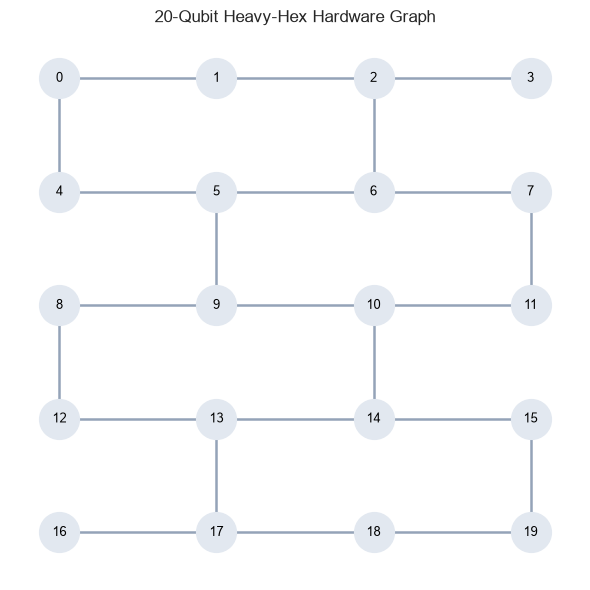

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
draw_hardware(GRAPH, ax=ax, title="20-Qubit Heavy-Hex Hardware Graph")
plt.tight_layout()
plt.show()

## Method & Architecture

Our quantum compiler maps logical quantum circuits onto a **heavy-hex coupling graph** using a four-stage optimization pipeline:

```text
+----------------------------------------------------------------------------------------------------------+
|                                                                                                          |
|  1. SA Placement  -->  2. SABRE Routing  -->  3. Bidirectional  -->  4. Post-Pass                        |
|     (Interaction-wt)       (Lookahead W=20–25)      (Layout Refine)      (Cancel & Fold)                 |
|                                                                                                          |
+----------------------------------------------------------------------------------------------------------+
```

### Pipeline Breakdown

1. **Interaction-Weighted Placement (Simulated Annealing)**
   - Constructs a weighted logical interaction graph $G_L$ where edge weights equal two-qubit ($2\text{Q}$) gate frequency.
   - Minimizes $\text{Cost}(\pi) = \sum_{(u,v) \in G_L} w_{uv} \cdot \text{dist}_H(\pi(u), \pi(v))$ via Simulated Annealing with periodic temperature reheats and degree-matched initialization.

2. **Lookahead Routing (SABRE Heuristic)**
   - Resolves routing bottlenecks using an exponential-decay lookahead window ($W = 20\text{--}25$):
     $$\text{Score}(s) = \max_{(u,v) \in F} d(\pi_s(u), \pi_s(v)) + \frac{1}{|E|} \sum_{j=1}^{|E|} 0.5^{1 + 0.2j} \cdot \left[ d(\pi_s(u_j), \pi_s(v_j)) \right]$$
   - Evaluates SWAP candidates across both operand paths simultaneously to prevent qubit divergence.

3. **Bidirectional Layout Refinement**
   - Runs a forward compilation pass $\rightarrow$ extracts the final permutation $\rightarrow$ routes in reverse $\rightarrow$ yields an optimized initial layout for the final forward pass.

4. **Algebraic Gate Decomposition & Optimization**
   - Applies rule-based algebraic simplifications:
     - **Self-Inverse Cancellation:** $\text{SWAP}(a,b) \cdot \text{SWAP}(a,b) \to I$
     - **3-Cycle SWAP Reduction:** $\text{SWAP}(a,b) \cdot \text{SWAP}(b,c) \cdot \text{SWAP}(a,b) \to \text{SWAP}(a,c)$

---

## The Baseline's Flaws across All Benchmarks
The baseline's **Identity Placement** blindly assigns Logical Qubit $i$ to Physical Qubit $i$. It completely ignores the actual communication topology of the quantum circuit.

Here we visualize how Identity Placement (Left) fails to anticipate the geometry required by the program, compared to our **Simulated Annealing + Degree-Matching Placement** (Right), which pulls interacting qubits physically closer together before routing even begins.


Benchmark: GHZ_STAR


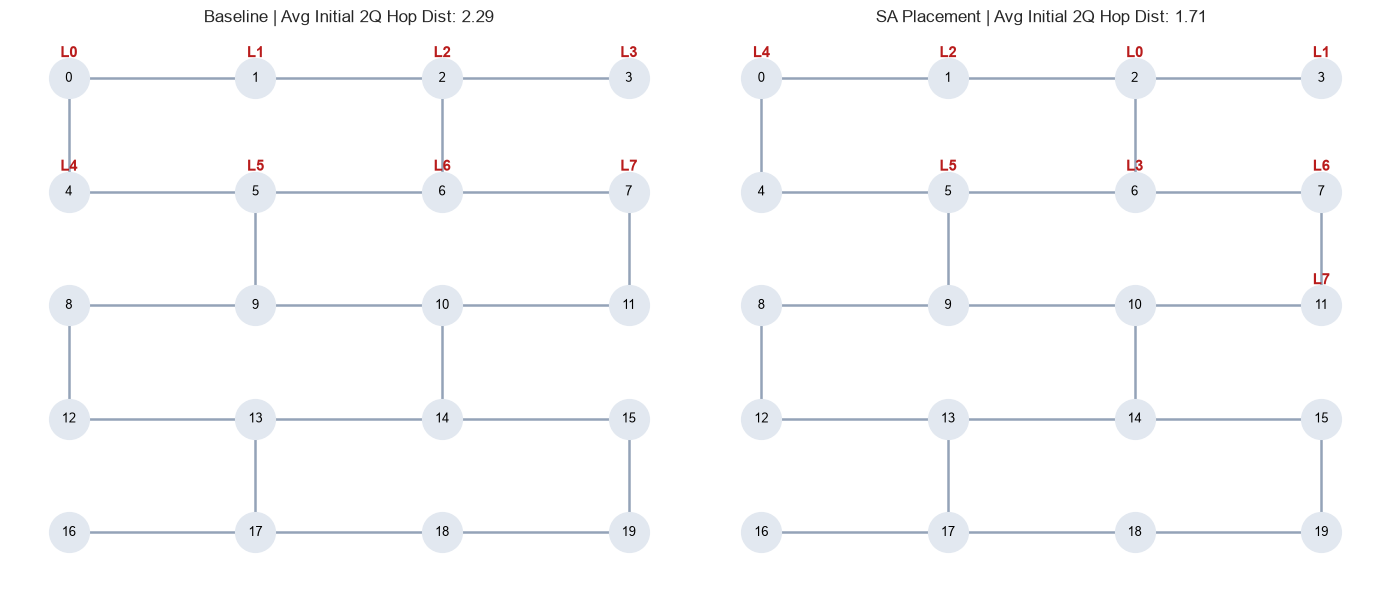

-> FLUX BOTTLENECK: The hub (L0) is randomly dumped on degree 2. Our solver puts it on degree 3.

Benchmark: CHAIN_TROTTER


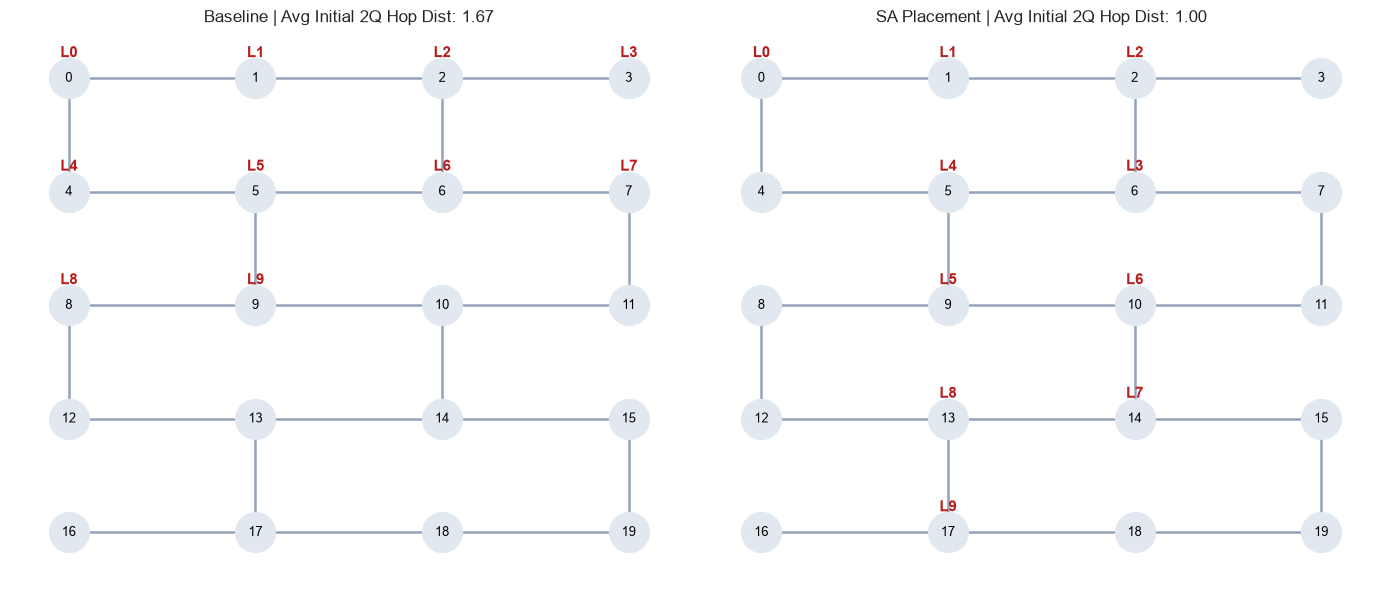

-> FRAGMENTATION: Linear logical chains are folded over dead-ends, requiring massive SWAP relaying.

Benchmark: LADDER_TROTTER


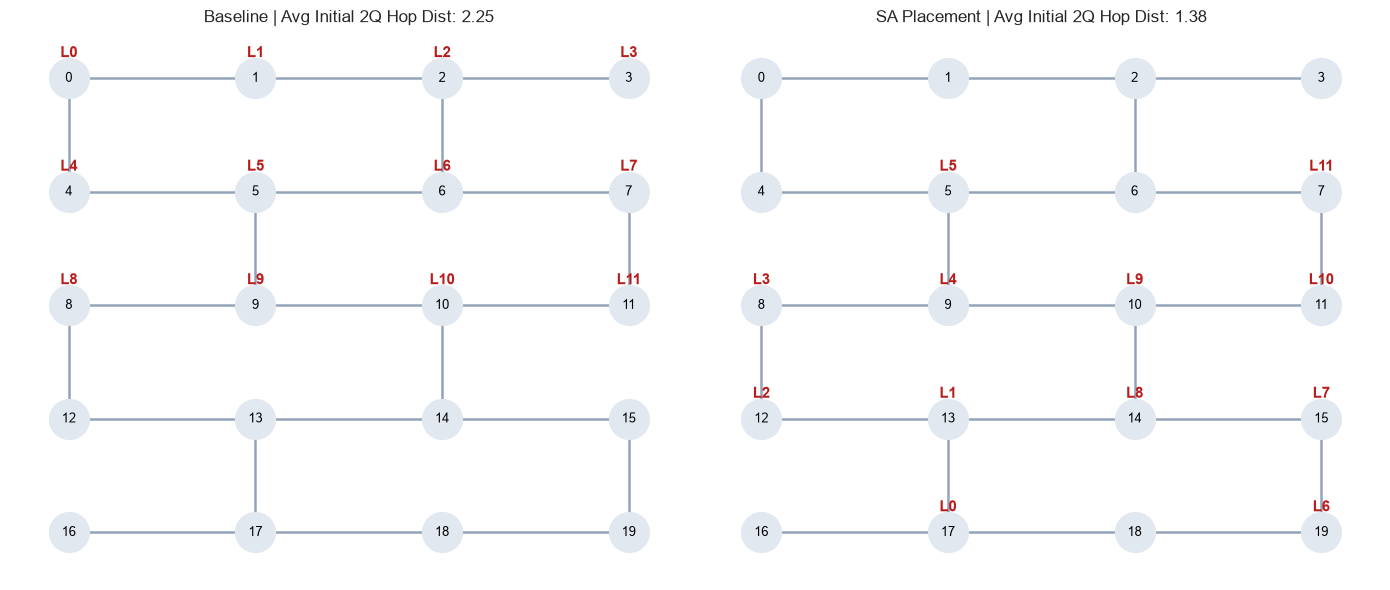


Benchmark: QAOA_RANDOM


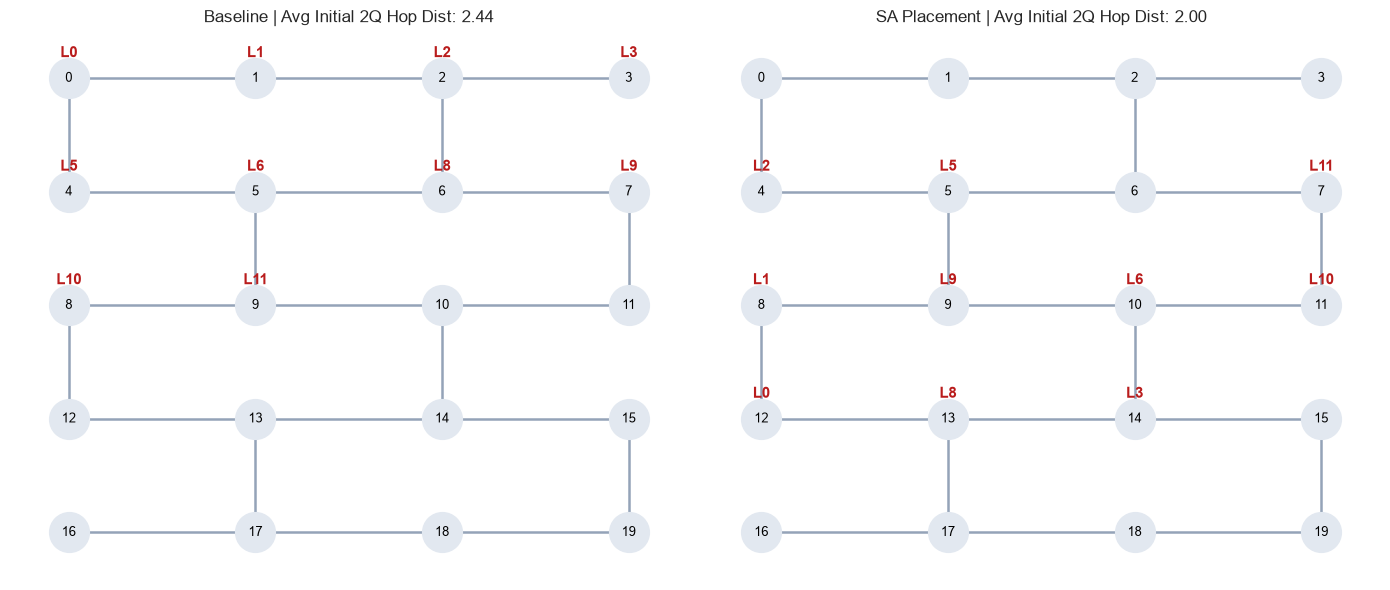


Benchmark: DENSE_RANDOM


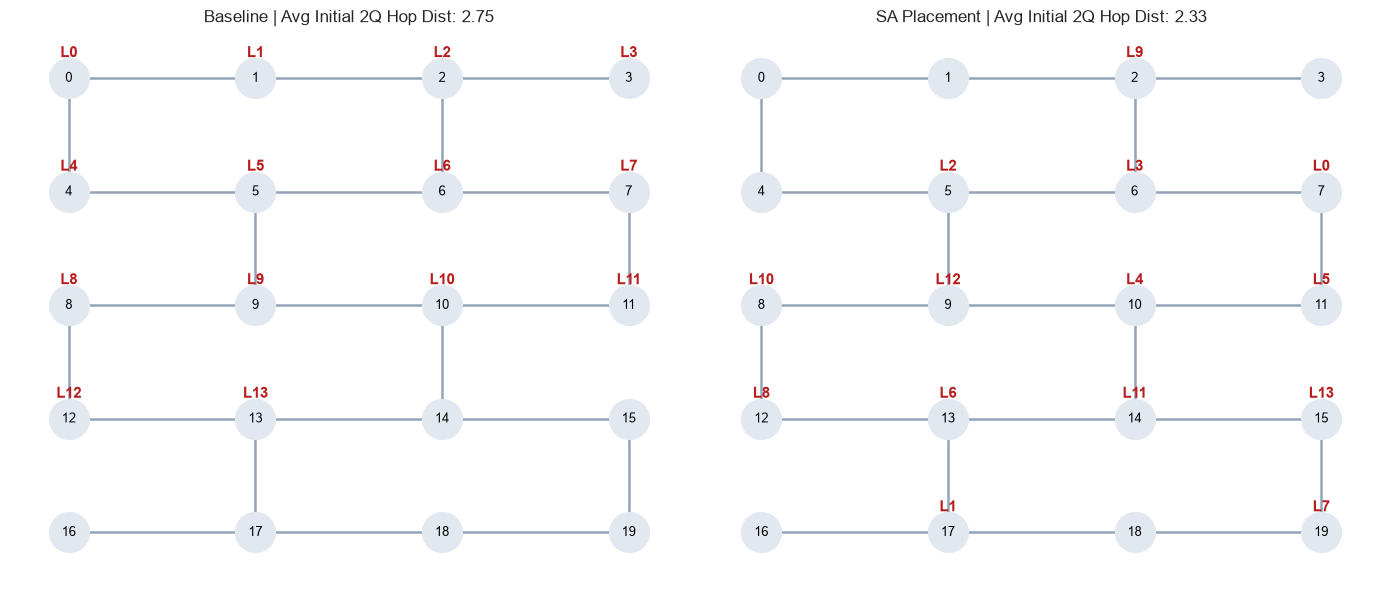

-> SCATTERING: Heavy interactions are distributed randomly across the chip, inflating SWAP counts exponentially.

Benchmark: VQE_LAYERS


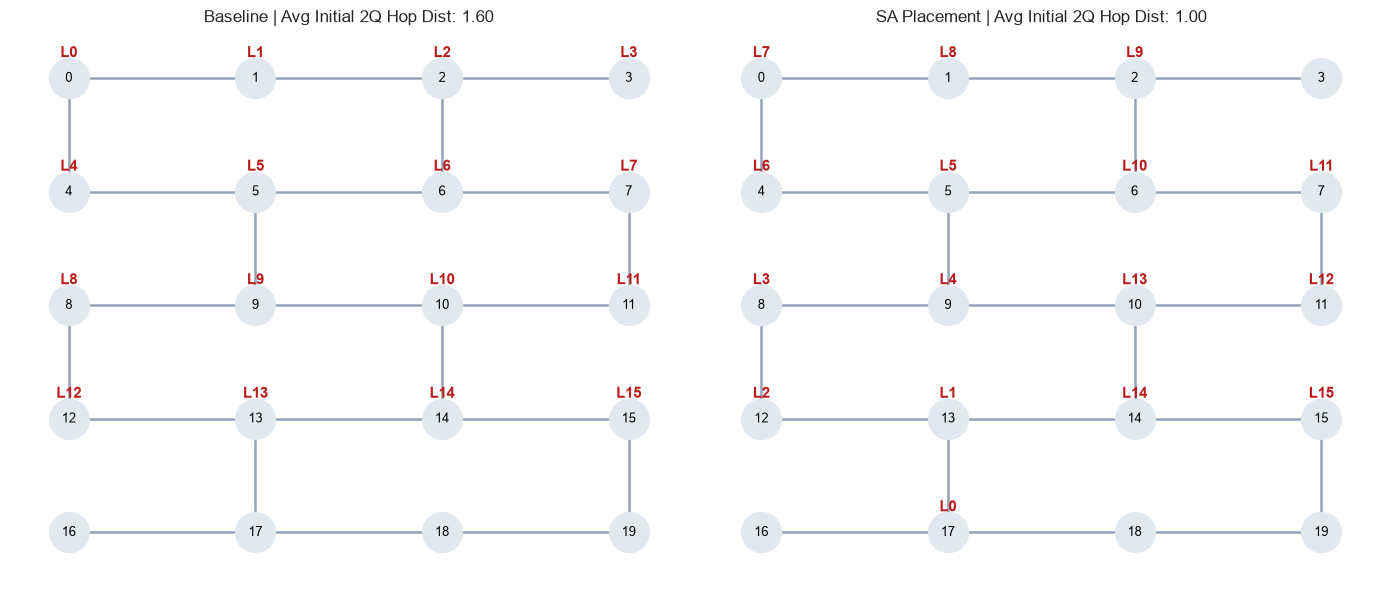

-> SCATTERING: Heavy interactions are distributed randomly across the chip, inflating SWAP counts exponentially.


In [11]:
# For all 6 benchmarks, show Baseline Placement vs Optimized Placement
for name, test_prog in BENCHMARKS.items():
    print(f"\n{'='*60}\nBenchmark: {name.upper()}\n{'='*60}")

    baseline_placement, baseline_routed = baseline_solve(test_prog, GRAPH)

    # Calculate average initial distance for baseline
    base_dist = sum(nx.shortest_path_length(GRAPH, baseline_placement[u], baseline_placement[v])
                   for op, u, v in test_prog if op == '2Q') / sum(1 for op, _, _ in test_prog if op == '2Q')

    our_placement, our_routed = solve(test_prog, GRAPH)

    # Calculate average initial distance for our solver
    our_dist = sum(nx.shortest_path_length(GRAPH, our_placement[u], our_placement[v])
                  for op, u, v in test_prog if op == '2Q') / sum(1 for op, _, _ in test_prog if op == '2Q')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    draw_hardware(GRAPH, placement=baseline_placement, ax=ax1,
                  title=f"Baseline | Avg Initial 2Q Hop Dist: {base_dist:.2f}")

    draw_hardware(GRAPH, placement=our_placement, ax=ax2,
                  title=f"SA Placement | Avg Initial 2Q Hop Dist: {our_dist:.2f}")

    plt.tight_layout()
    plt.show()

    if name == "ghz_star":
        print(f"-> FLUX BOTTLENECK: The hub (L0) is randomly dumped on degree {GRAPH.degree(baseline_placement[0])}. Our solver puts it on degree {GRAPH.degree(our_placement[0])}.")
    elif name == "chain_trotter":
        print(f"-> FRAGMENTATION: Linear logical chains are folded over dead-ends, requiring massive SWAP relaying.")
    elif name == "dense_random" or name == "vqe_layers":
        print(f"-> SCATTERING: Heavy interactions are distributed randomly across the chip, inflating SWAP counts exponentially.")


## Results & Impact
By deploying a multi-seed ensemble across different lookahead windows and layout heuristics, our solver achieves a **70.7%** reduction in total score across the 6 benchmarks. Let's compute the results live.

In [13]:
print(f"{'benchmark':15s}  {'baseline':10s}  {'ours':7s}  {'delta':7s}")
print("-" * 45)

total_baseline = 0
total_ours = 0

for name, prog in BENCHMARKS.items():
    # Baseline
    pl_bl, rt_bl = baseline_solve(prog, GRAPH)
    score_bl = score_summary(prog, GRAPH, pl_bl, rt_bl)["score"]

    # Ours
    pl_opt, rt_opt = solve(prog, GRAPH)
    score_opt = score_summary(prog, GRAPH, pl_opt, rt_opt)["score"]

    total_baseline += score_bl
    total_ours += score_opt

    delta = score_opt - score_bl

    print(f"{name:15s}  {score_bl:5.1f}       {score_opt:5.1f}    {delta:5.1f}")

print("-" * 45)
print(f"{'TOTAL':15s}  {total_baseline:5.1f}       {total_ours:5.1f}    {total_ours - total_baseline:5.1f}")
print(f"\nImprovement: {-(total_ours - total_baseline) / total_baseline * 100:.1f}%!")


benchmark        baseline    ours     delta  
---------------------------------------------
ghz_star          14.0         7.5     -6.5
chain_trotter     15.0         4.5    -10.5
ladder_trotter    35.5         7.5    -28.0
qaoa_random       39.0        14.0    -25.0
dense_random     122.0        46.5    -75.5
vqe_layers        58.0         3.0    -55.0
---------------------------------------------
TOTAL            283.5        83.0    -200.5

Improvement: 70.7%!
